# Исследование фичей для pump.fun токенов

## О чём этот ноутбук?

У нас есть таблица с 3231 токеном pump.fun и 77 разных характеристик (фичей) про каждый токен. Нужно узнать:

**Какие из этих 77 фичей помогают предсказать, сильно ли токен вырастет в цене?**

В датасете 75 базовых фичей + 2 новые (`heavy_seller_count_fw`, `heavy_seller_ratio_fw` — количество и доля кошельков которые продавали в 2x+ больше чем покупали).

Цена роста (наша цель) — это число `x_excl_top1_3h_h`. Например если токен вырос в 7 раз, то `x=7`. Если упал в 2 раза, то `x=0.5`.

## Что мы делаем?

Для каждой фичи по отдельности проверяем: есть ли связь между значением фичи и ростом цены? Используем *6 разных способов* чтобы убедиться что связь реальная а не случайная.

## Почему 6 способов?

Потому что одна метрика может обмануть. Например:
- Одна фича может расти вместе с ценой (Spearman увидит это)
- Другая может только в top-10% давать сильный рост (top-decile metric увидит это)
- Третья имеет U-образную зависимость (квадратичный fit)

Если фича *одновременно* показывает сигнал по нескольким метрикам — значит она реально полезная.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib as mpl

# Настройки отрисовки
mpl.rcParams['figure.dpi'] = 100
plt.style.use('default')

# Загружаем данные
MATRIX_PATH = "/tmp/b_prime_dataset_export/b_prime_training_matrix_xcont_77.csv"
df = pd.read_csv(MATRIX_PATH)
TARGET = "x_excl_top1_3h_h"
features = [c for c in df.columns if c != TARGET]
y = df[TARGET].values  # наша целевая переменная — сколько раз вырос токен
y_log = np.log1p(y)     # логарифм — сглаживает экстремальные значения

print(f"Размер данных: {df.shape}")
print(f"Кол-во фичей: {len(features)}")
print(f"\nСтатистика таргета (сколько x вырос токен):")
print(df[TARGET].describe())

Размер данных: (3231, 78)
Кол-во фичей: 77

Статистика таргета (сколько x вырос токен):
count    3231.000000
mean        7.818739
std       181.096307
min         0.046601
25%         1.178170
50%         1.575054
75%         2.796258
max      9304.445670
Name: x_excl_top1_3h_h, dtype: float64


## 1. Посмотрим на распределение таргета

**ELI5**: Показываем гистограмму — сколько токенов выросло в 1x, 2x, 5x, 10x и т.д.

**Зачем**: понять насколько "хвостистое" распределение. Если большинство токенов падает/стоит а меньшинство взлетает в 100x+ — нужно работать с log-шкалой иначе графики ничего не покажут.

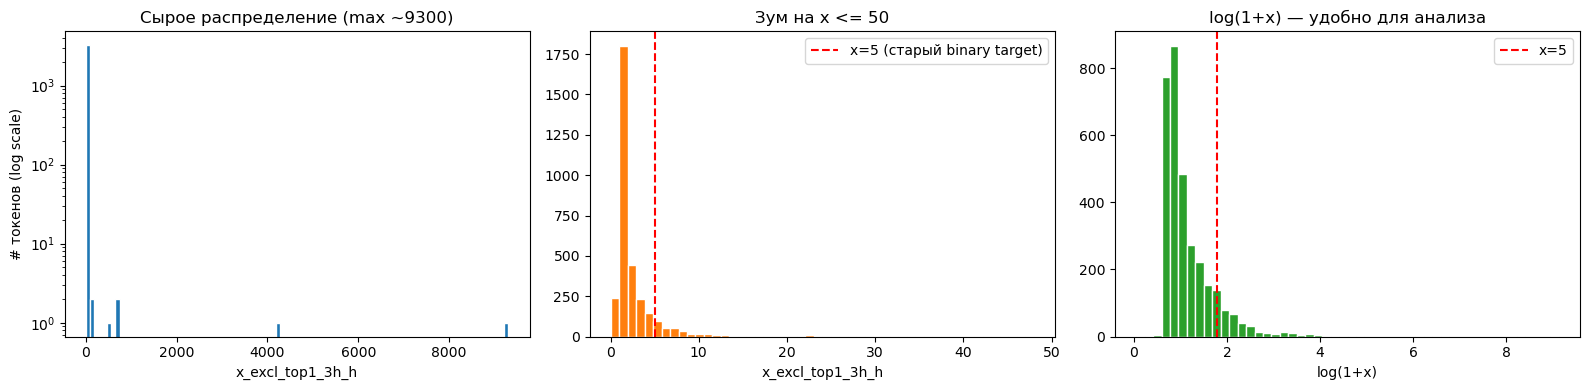

Квантили сырого таргета:
  квантиль 0.05: x =    1.000
  квантиль 0.10: x =    1.019
  квантиль 0.25: x =    1.178
  квантиль 0.50: x =    1.575
  квантиль 0.75: x =    2.796
  квантиль 0.90: x =    5.308
  квантиль 0.95: x =    8.209
  квантиль 0.99: x =   31.474

Токенов с x >= 5: 11.05% — это наш baseline rate
Токенов с x >= 2: 36.27%
Токенов с x >= 1: 95.85%


In [2]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(y, bins=100, color='C0', edgecolor='white')
ax[0].set_title('Сырое распределение (max ~9300)')
ax[0].set_xlabel('x_excl_top1_3h_h')
ax[0].set_ylabel('# токенов (log scale)')
ax[0].set_yscale('log')

ax[1].hist(y[y<=50], bins=50, color='C1', edgecolor='white')
ax[1].set_title('Зум на x <= 50')
ax[1].set_xlabel('x_excl_top1_3h_h')
ax[1].axvline(5, color='red', linestyle='--', label='x=5 (старый binary target)')
ax[1].legend()

ax[2].hist(y_log, bins=50, color='C2', edgecolor='white')
ax[2].set_title('log(1+x) — удобно для анализа')
ax[2].set_xlabel('log(1+x)')
ax[2].axvline(np.log1p(5), color='red', linestyle='--', label='x=5')
ax[2].legend()
plt.tight_layout()
plt.show()

print('Квантили сырого таргета:')
for q in [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f'  квантиль {q:.2f}: x = {np.quantile(y, q):8.3f}')
print(f'\nТокенов с x >= 5: {(y>=5).mean()*100:.2f}% — это наш baseline rate')
print(f'Токенов с x >= 2: {(y>=2).mean()*100:.2f}%')
print(f'Токенов с x >= 1: {(y>=1).mean()*100:.2f}%')

### Выводы по распределению

- Медиана x = 1.6 — средний токен вырос в 1.6 раз (скромно)
- Максимум x = 9300 — какой-то токен взлетел в 9000+ раз
- Распределение **экстремально правостороннее** (heavy right tail)
- Поэтому все корреляции считаем на log-шкале

## 2. Метрики влияния фичи на таргет

Для каждой из 75 фичей вычислим 6 метрик. Вот что они означают:

### Метрика 1: Spearman correlation (ранговая корреляция)
**ELI5**: Отсортируй токены по фиче. Отсортируй те же токены по таргету. Насколько эти порядки совпадают? 1 = идеально одинаково, 0 = случайно, -1 = обратная связь.

**Почему ранговая**: устойчивая к выбросам. Неважно что max x = 9000, главное что он на последнем месте.

### Метрика 2: Pearson на log(target)
**ELI5**: Классическая "линейная" корреляция, но на log-шкале таргета. Измеряет насколько точно прямая линия ложится на облако (feature, log_target).

### Метрика 3: Decile monotonicity R²
**ELI5**: Разрезаем токены на 10 равных групп по значению фичи (децили). Для каждой группы считаем медиану таргета. Если с ростом децили медиана таргета **строго растёт** — R² близок к 1. Если прыгает туда-сюда — R² низкий.

**Зачем**: ловит *монотонный* dose-response. "Больше фичи → больше таргета" или наоборот.

### Метрика 4: MSE reduction (уменьшение дисперсии)
**ELI5**: Это аналог Gini для регрессии. Ищем такое пороговое значение фичи, что после разбиения на две группы **дисперсия таргета внутри групп минимальна**. Насколько упала общая дисперсия = насколько фича помогает предсказать.

**Зачем**: аналог "лучшего единичного split в дереве решений".

### Метрика 5: Top vs bottom decile log-lift
**ELI5**: Сравниваем медианный log(target) у топ-10% токенов (по фиче) и bottom-10%. Насколько сильно различается?

### Метрика 6: Top-decile P(target >= 5)
**ELI5**: Среди топ-10% токенов по фиче — какая доля достигла x >= 5? Это **практическая precision** если бы мы торговали по одной фиче.

In [3]:
def decile_monotonicity_r2(x, y_log_arr):
    """R² линейного тренда медиан по децилям."""
    q_edges = np.quantile(x, np.linspace(0, 1, 11))
    q_edges = np.unique(q_edges)
    if len(q_edges) < 3:
        return 0.0
    bins = np.digitize(x, q_edges[1:-1])
    med = np.array([np.median(y_log_arr[bins == i])
                    for i in range(len(q_edges)-1) if (bins==i).sum() > 0])
    if len(med) < 3:
        return 0.0
    ranks = np.arange(len(med))
    slope, intercept, r, p, se = stats.linregress(ranks, med)
    return r ** 2


def best_split_mse_reduction(x, y_arr, min_side=30):
    """Аналог Gini для регрессии."""
    order = np.argsort(x)
    x_s = x[order]; y_s = y_arr[order]
    n = len(y_s)
    if n < 2 * min_side:
        return 0.0
    cum_y = np.cumsum(y_s)
    cum_y2 = np.cumsum(y_s * y_s)
    total_y = cum_y[-1]; total_y2 = cum_y2[-1]
    total_mse = (total_y2 - total_y * total_y / n) / n
    i_arr = np.arange(n - 1)
    n_l = i_arr + 1; n_r = n - n_l
    y_sum_l = cum_y[:-1]; y_sum_r = total_y - y_sum_l
    y2_sum_l = cum_y2[:-1]; y2_sum_r = total_y2 - y2_sum_l
    mse_l = (y2_sum_l - y_sum_l**2 / n_l) / n_l
    mse_r = (y2_sum_r - y_sum_r**2 / n_r) / n_r
    weighted = (n_l * mse_l + n_r * mse_r) / n
    valid = (n_l >= min_side) & (n_r >= min_side) & (x_s[:-1] != x_s[1:])
    if not valid.any():
        return 0.0
    weighted[~valid] = np.inf
    return float(total_mse - weighted.min())


def top_decile_frac(x, y_arr, thr=5.0, q=0.9):
    q_val = np.quantile(x, q)
    top = y_arr[x >= q_val]
    if len(top) == 0: return 0.0
    return float((top >= thr).mean())


def bottom_decile_frac(x, y_arr, thr=5.0, q=0.1):
    q_val = np.quantile(x, q)
    bot = y_arr[x <= q_val]
    if len(bot) == 0: return 0.0
    return float((bot >= thr).mean())


print(f'Считаю метрики для {len(features)} фичей...')
rows = []
base_rate_5x = (y >= 5).mean()

for f in features:
    x = df[f].values.astype(float)
    if np.all(x == x[0]):  # константа — пропустить
        continue
    sp, sp_p = stats.spearmanr(x, y)
    pe_log, _ = stats.pearsonr(x, y_log)
    monot_r2 = decile_monotonicity_r2(x, y_log)
    mse_red = best_split_mse_reduction(x, y)
    top_med_log = np.median(np.log1p(y[x >= np.quantile(x, 0.9)]))
    bot_med_log = np.median(np.log1p(y[x <= np.quantile(x, 0.1)]))
    decile_med_lift_log = top_med_log - bot_med_log
    top_5x = top_decile_frac(x, y)
    bot_5x = bottom_decile_frac(x, y)
    rows.append({
        'feature': f,
        'spearman': sp,
        'pearson_on_logy': pe_log,
        'decile_monot_r2_signed': monot_r2 * np.sign(sp),  # знак от Spearman
        'mse_reduction': mse_red,
        'decile_med_lift_log': decile_med_lift_log,
        'top_decile_5x_rate': top_5x,
        'bottom_decile_5x_rate': bot_5x,
        'top_over_bottom_5x_ratio': top_5x / bot_5x if bot_5x > 0 else float('inf'),
    })

summary = pd.DataFrame(rows)
summary.to_csv('/tmp/feature_research/feature_influence_summary.csv', index=False)
print(f'Готово. Сохранил: /tmp/feature_research/feature_influence_summary.csv')
print(f'Base rate (доля токенов с x >= 5): {base_rate_5x:.4f}')
print(f'Всего строк в summary: {len(summary)}')

Считаю метрики для 77 фичей...
Готово. Сохранил: /tmp/feature_research/feature_influence_summary.csv
Base rate (доля токенов с x >= 5): 0.1105
Всего строк в summary: 77


## 3. Рейтинги по каждой метрике отдельно

**ELI5**: Сейчас покажем топ-20 фичей по каждой метрике отдельно. Если фича попадает в топ по нескольким метрикам — это хороший знак.

In [4]:
print('ТОП-20 по |Spearman| (самая прямолинейная связь):')
print('(чем больше |spearman|, тем сильнее фича движется вместе с таргетом)\n')
print((summary.reindex(summary['spearman'].abs().sort_values(ascending=False).index)
       [['feature', 'spearman', 'pearson_on_logy', 'decile_monot_r2_signed',
         'mse_reduction', 'top_decile_5x_rate', 'top_over_bottom_5x_ratio']]
       .head(20).to_string(index=False, float_format=lambda x: f'{x:.4f}')))

ТОП-20 по |Spearman| (самая прямолинейная связь):
(чем больше |spearman|, тем сильнее фича движется вместе с таргетом)

                            feature  spearman  pearson_on_logy  decile_monot_r2_signed  mse_reduction  top_decile_5x_rate  top_over_bottom_5x_ratio
                pa_price_change_pct    0.2167           0.0101                  0.7260        51.1834              0.1914                    1.9375
            pa_velocity_pct_per_sec    0.2152           0.0103                  0.7278        50.8117              0.1914                    2.0000
top20_avg_unrealized_profit_pct_ext    0.2117           0.0175                  0.7264        54.4728              0.1420                    1.6429
                   pa_buy_vol_share    0.2071           0.1271                  0.8187        24.4947              0.1790                    2.5217
                         cutoff_cap    0.2008           0.0091                  0.8638       157.0488              0.1790                   

In [5]:
print('ТОП-20 по MSE reduction (лучший single-split):')
print('(чем больше, тем лучше фича разделяет токены с высоким x и низким x)\n')
print((summary.sort_values('mse_reduction', ascending=False)
       [['feature', 'spearman', 'pearson_on_logy', 'decile_monot_r2_signed',
         'mse_reduction', 'top_decile_5x_rate']]
       .head(20).to_string(index=False, float_format=lambda x: f'{x:.4f}')))

ТОП-20 по MSE reduction (лучший single-split):
(чем больше, тем лучше фича разделяет токены с высоким x и низким x)

                        feature  spearman  pearson_on_logy  decile_monot_r2_signed  mse_reduction  top_decile_5x_rate
                pa_acceleration   -0.0077          -0.0070                 -0.0805       982.8853              0.1698
         pa_vol_first_30s_share   -0.1088          -0.0624                 -0.4098       903.7659              0.1019
             pa_buyer_diversity    0.0432          -0.0284                  0.3114       616.1370              0.1265
           sn_avg_buy_per_buyer   -0.0432           0.0451                 -0.2748       616.1370              0.1790
                 buy_count_gini   -0.0985          -0.0141                 -0.7256       574.2945              0.1852
      sn_buys_in_first_3_blocks    0.0937           0.0473                  0.8400       521.2676              0.1408
               deals_count_gini   -0.0618           0.022

In [6]:
print('ТОП-20 по monotonicity R² (дисциплинированный dose-response):')
print('(чем выше, тем ровнее зависимость медианы таргета от децили фичи)\n')
print((summary.reindex(summary['decile_monot_r2_signed'].abs().sort_values(ascending=False).index)
       [['feature', 'spearman', 'decile_monot_r2_signed',
         'mse_reduction', 'top_decile_5x_rate', 'top_over_bottom_5x_ratio']]
       .head(20).to_string(index=False, float_format=lambda x: f'{x:.4f}')))

ТОП-20 по monotonicity R² (дисциплинированный dose-response):
(чем выше, тем ровнее зависимость медианы таргета от децили фичи)

                            feature  spearman  decile_monot_r2_signed  mse_reduction  top_decile_5x_rate  top_over_bottom_5x_ratio
                      kolscan_count   -0.0298                 -0.9466        15.7653              0.0732                    0.5812
             amount_of_instructions   -0.0762                 -0.8851        20.2905              0.0778                    0.6383
                         cutoff_cap    0.2008                  0.8638       157.0488              0.1790                    1.2340
          sn_buys_in_first_3_blocks    0.0937                  0.8400       521.2676              0.1408                    1.1994
                   pa_buy_vol_share    0.2071                  0.8187        24.4947              0.1790                    2.5217
                  pa_buy_sell_ratio    0.1534                  0.8073        26.5822 

In [7]:
print('ТОП-20 по top-decile 5x-rate (практическая precision в топ-10% по фиче):')
print('(базовый rate = 11%. Насколько лучше чем случайный выбор?)\n')
print((summary.sort_values('top_decile_5x_rate', ascending=False)
       [['feature', 'spearman', 'top_decile_5x_rate', 'bottom_decile_5x_rate',
         'top_over_bottom_5x_ratio', 'mse_reduction']]
       .head(20).to_string(index=False, float_format=lambda x: f'{x:.4f}')))

ТОП-20 по top-decile 5x-rate (практическая precision в топ-10% по фиче):
(базовый rate = 11%. Насколько лучше чем случайный выбор?)

                         feature  spearman  top_decile_5x_rate  bottom_decile_5x_rate  top_over_bottom_5x_ratio  mse_reduction
           top20_token_share_ext    0.1388              0.2160                 0.0988                    2.1875       396.7673
                pa_max_runup_pct    0.1149              0.2068                 0.0864                    2.3929        71.2514
         pa_velocity_pct_per_sec    0.2152              0.1914                 0.0957                    2.0000        50.8117
             pa_price_change_pct    0.2167              0.1914                 0.0988                    1.9375        51.1834
 top20_unrealized_profit_usd_ext    0.1668              0.1914                 0.1358                    1.4091        95.8996
volume_weighted_price_change_ext    0.1119              0.1883                 0.1944                    

## 4. Общий рейтинг (combined score)

**ELI5**: Чтобы объединить 6 метрик в одно число:
1. Каждую метрику масштабируем в [0, 1] — где 1 = лучшее значение среди всех фичей
2. Складываем все 6 нормированных значений

Фича с высоким combined score — *лидер сразу по нескольким метрикам*. Это самый надёжный сигнал.

In [8]:
def rescale01(s):
    s = s.abs()
    s_min = s.min(); s_max = s.max()
    if s_max == s_min: return s * 0
    return (s - s_min) / (s_max - s_min)

combo_cols = ['spearman', 'pearson_on_logy', 'decile_monot_r2_signed',
              'mse_reduction', 'decile_med_lift_log', 'top_decile_5x_rate']
combo = summary.copy()
for c in combo_cols:
    combo[f'{c}_n'] = rescale01(summary[c])
combo['combined_score'] = combo[[f'{c}_n' for c in combo_cols]].sum(axis=1)
combo_sorted = combo.sort_values('combined_score', ascending=False).reset_index(drop=True)

print('ТОП-25 по combined score:')
print(combo_sorted.head(25)[['feature', 'spearman', 'pearson_on_logy', 'mse_reduction',
                              'top_decile_5x_rate', 'combined_score']].to_string(index=False,
    float_format=lambda x: f'{x:.4f}'))

ТОП-25 по combined score:
                            feature  spearman  pearson_on_logy  mse_reduction  top_decile_5x_rate  combined_score
              top20_token_share_ext    0.1388           0.2085       396.7673              0.2160          4.4363
                   pa_buy_vol_share    0.2071           0.1271        24.4947              0.1790          4.0164
                pa_price_change_pct    0.2167           0.0101        51.1834              0.1914          3.7216
            pa_velocity_pct_per_sec    0.2152           0.0103        50.8117              0.1914          3.7137
                         cutoff_cap    0.2008           0.0091       157.0488              0.1790          3.5738
top20_avg_unrealized_profit_pct_ext    0.2117           0.0175        54.4728              0.1420          3.3230
    top20_unrealized_profit_usd_ext    0.1668           0.0092        95.8996              0.1914          3.2379
                  pa_buy_sell_ratio    0.1534           0.0692

## 5. Детальный разбор топ-10 фичей

**ELI5**: Для каждой топ-10 фичи делаем 2 картинки:

**Левая картинка** — анализ по децилям:
- X: номер децили фичи (0 = самые низкие значения, 9 = самые высокие)
- Y левая ось: медианный log(target) для токенов в этой децили (синяя линия)
- Y правая ось: доля токенов с x >= 5 (красная линия)
- Видим: как меняется таргет с ростом фичи?

**Правая картинка** — scatter:
- X: сырое значение фичи
- Y: log(1+target)
- Каждая точка — один токен
- Видим: облако зависимости

ТОП-10 фичей (которые сейчас будем разбирать):
   1. top20_token_share_ext
   2. pa_buy_vol_share
   3. pa_price_change_pct
   4. pa_velocity_pct_per_sec
   5. cutoff_cap
   6. top20_avg_unrealized_profit_pct_ext
   7. top20_unrealized_profit_usd_ext
   8. pa_buy_sell_ratio
   9. pa_vol_first_30s_share
  10. volume_weighted_price_change_ext


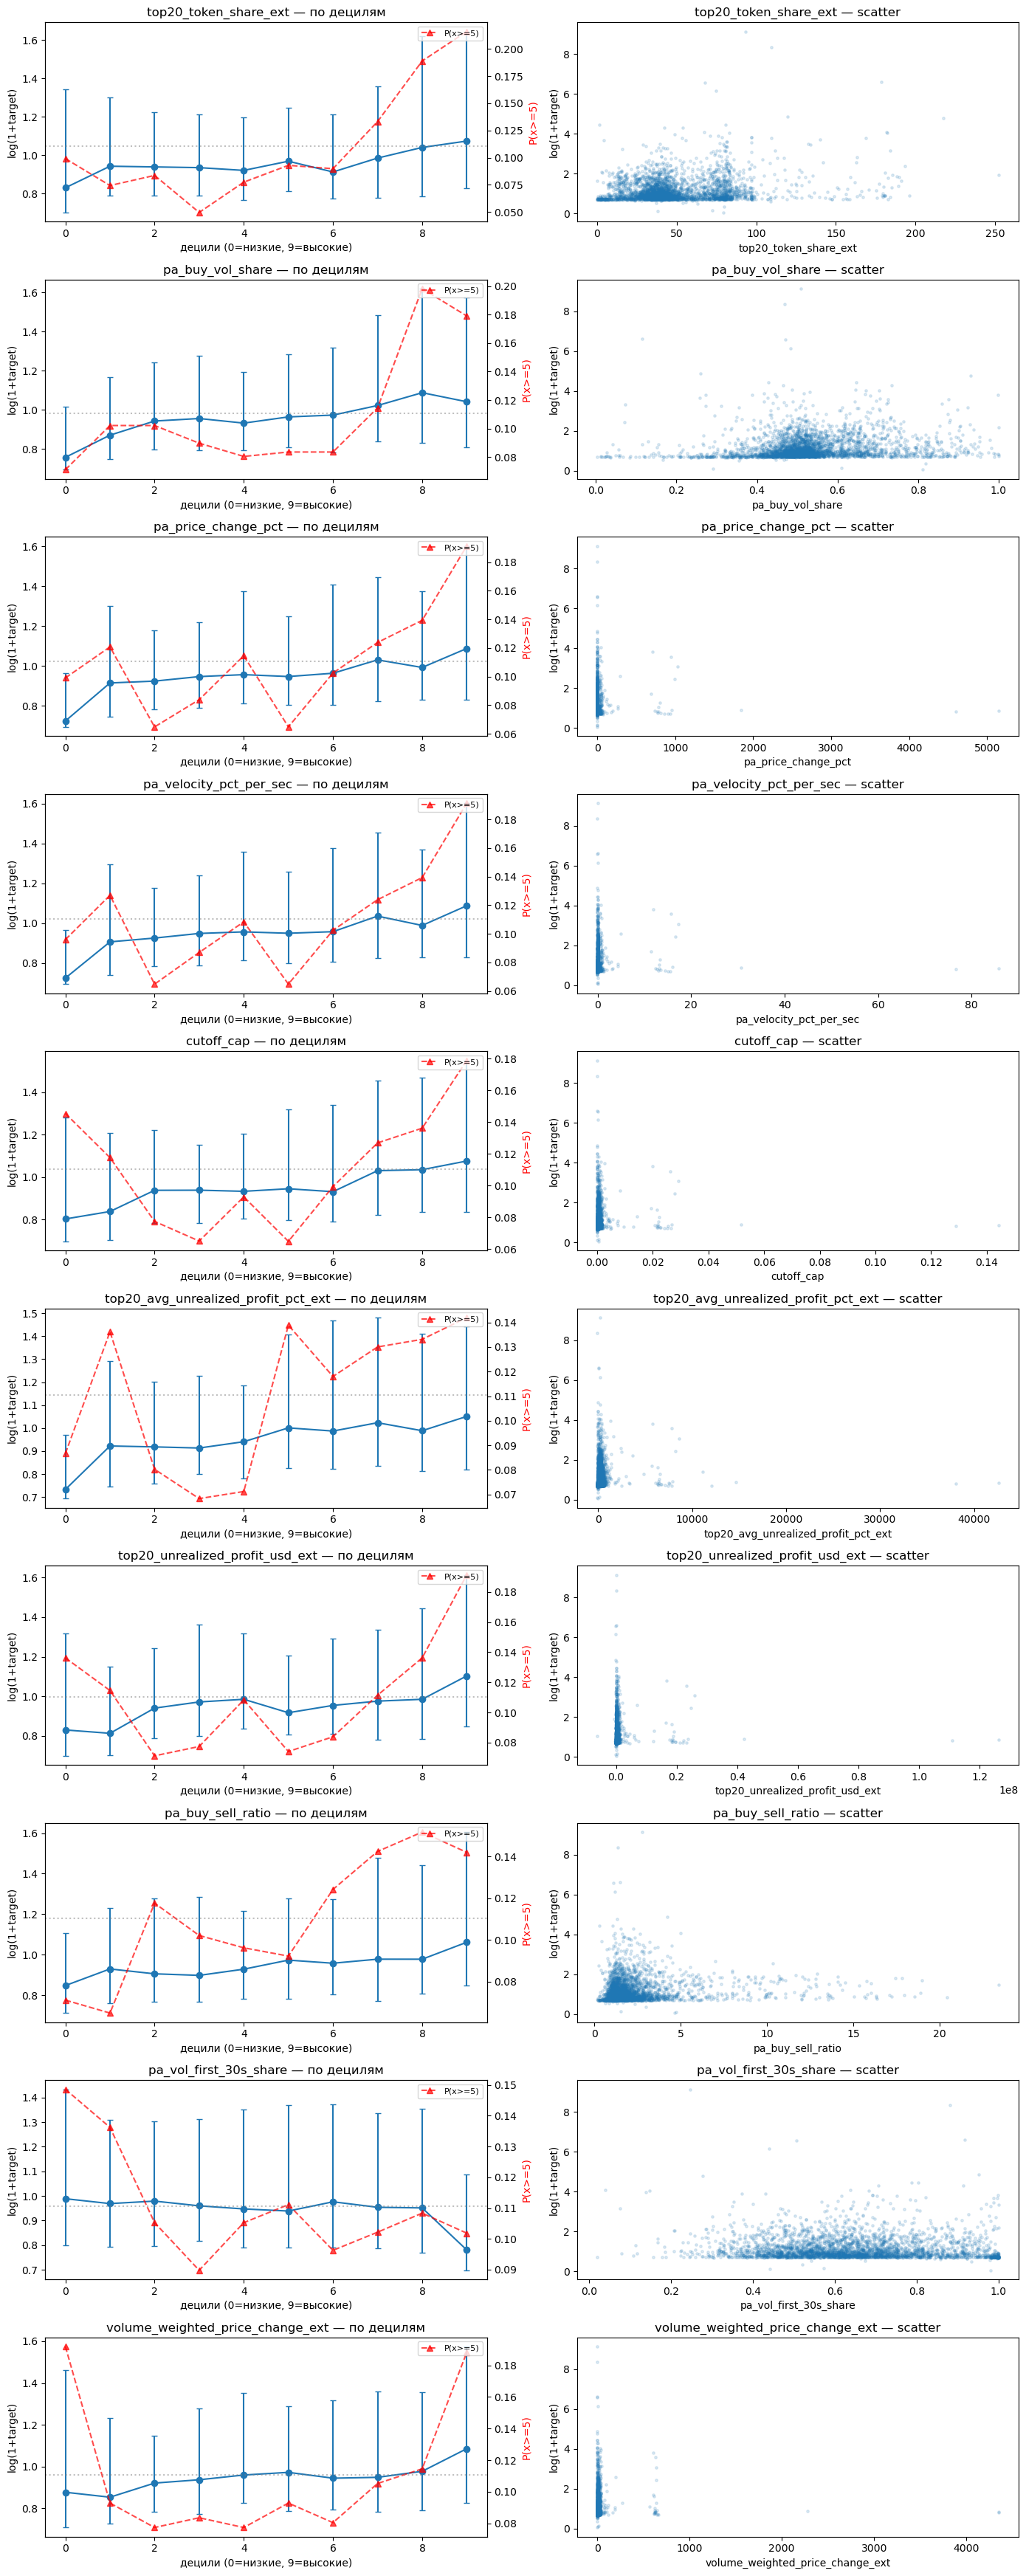

In [9]:
top10 = combo_sorted.head(10)['feature'].tolist()
print('ТОП-10 фичей (которые сейчас будем разбирать):')
for i, f in enumerate(top10, 1):
    print(f'  {i:2d}. {f}')

fig, axes = plt.subplots(10, 2, figsize=(14, 3.5 * 10))
for i, feat in enumerate(top10):
    x = df[feat].values.astype(float)
    q_edges = np.quantile(x, np.linspace(0, 1, 11))
    q_edges = np.unique(q_edges)
    bins = np.digitize(x, q_edges[1:-1])

    decile_stats = []
    for b in range(len(q_edges) - 1):
        m = bins == b
        if m.sum() == 0: continue
        yy = y[m]
        decile_stats.append({
            'bin': b, 'n': m.sum(),
            'med': np.median(yy), 'p25': np.quantile(yy, 0.25), 'p75': np.quantile(yy, 0.75),
            'frac_ge_5': (yy >= 5).mean(),
            'med_log': np.median(np.log1p(yy)),
        })
    ds = pd.DataFrame(decile_stats)

    # Левый график — децили
    ax = axes[i, 0]
    ax.errorbar(ds['bin'], ds['med_log'],
                yerr=[ds['med_log'] - np.log1p(ds['p25']), np.log1p(ds['p75']) - ds['med_log']],
                marker='o', capsize=3, color='C0', label='медиана log(1+x)')
    ax.set_title(f'{feat} — по децилям')
    ax.set_xlabel('децили (0=низкие, 9=высокие)')
    ax.set_ylabel('log(1+target)')
    ax2 = ax.twinx()
    ax2.plot(ds['bin'], ds['frac_ge_5'], 'r^--', alpha=0.7, label='P(x>=5)')
    ax2.set_ylabel('P(x>=5)', color='r')
    ax2.axhline(0.1105, color='gray', linestyle=':', alpha=0.5)
    ax2.legend(loc='upper right', fontsize=8)

    # Правый график — scatter
    ax = axes[i, 1]
    ax.scatter(x, y_log, alpha=0.15, s=6)
    ax.set_title(f'{feat} — scatter')
    ax.set_xlabel(feat)
    ax.set_ylabel('log(1+target)')
plt.tight_layout()
plt.savefig('/tmp/feature_research/top10_features.png', dpi=110, bbox_inches='tight')
plt.show()

### Как читать эти графики?

- **Если синяя линия растёт** от левого края до правого → фича положительно связана с таргетом
- **Если падает** → отрицательно связана
- **Если прыгает туда-сюда** → связи нет
- **Красная линия выше серой (base rate 11%)** → фича реально выделяет высоковероятные токены в своих децилях

## 6. Корреляция между топ фичами

**ELI5**: Если две топ-фичи сильно коррелируют друг с другом (>0.8), то они говорят одно и то же — можно оставить одну и не терять сигнал.

Показываем **Spearman correlation** между топ-15 фичами.

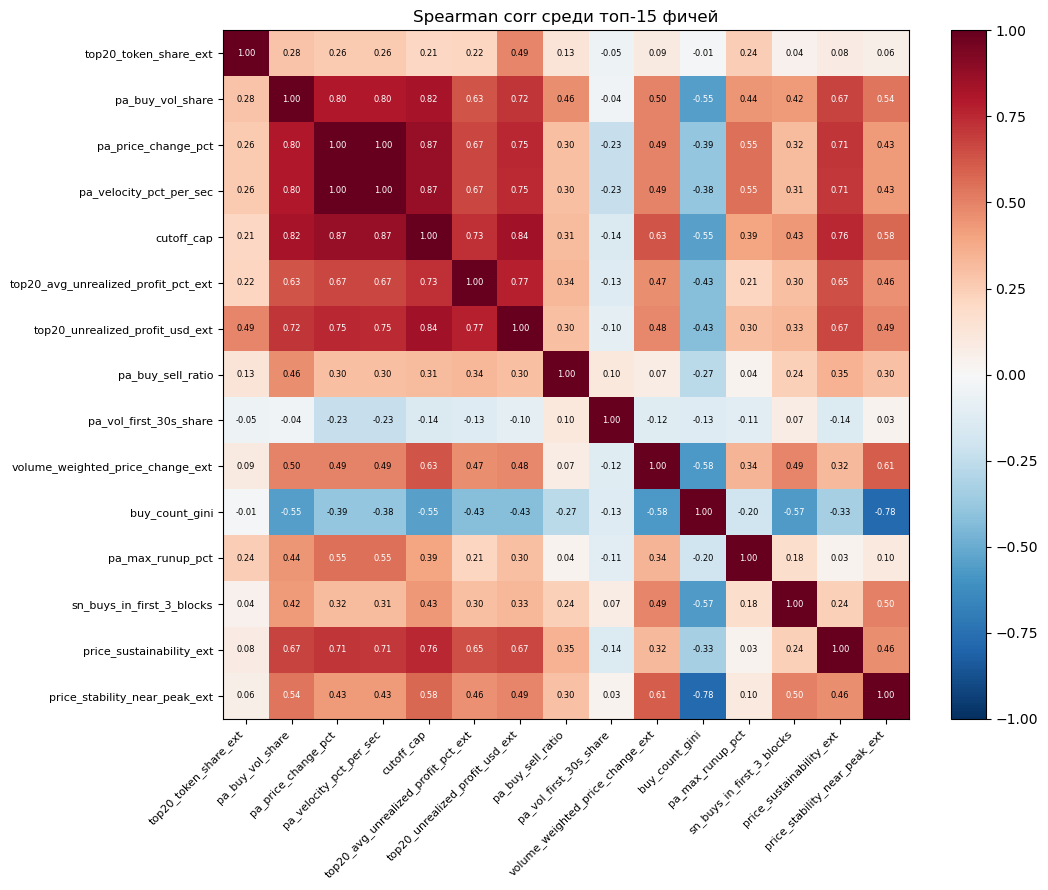

In [10]:
top15 = combo_sorted.head(15)['feature'].tolist()
corr_m = df[top15].corr(method='spearman')
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_m, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(15)); ax.set_xticklabels(top15, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(15)); ax.set_yticklabels(top15, fontsize=8)
for i in range(15):
    for j in range(15):
        val = corr_m.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=6)
ax.set_title('Spearman corr среди топ-15 фичей')
plt.tight_layout()
plt.savefig('/tmp/feature_research/top15_correlation.png', dpi=110, bbox_inches='tight')
plt.show()

### Как читать?

- **Красные ячейки (1.0)** — фичи говорят про одно и то же. Можно выкинуть одну из них.
- **Тёмно-красные (>0.8)** — сильная корреляция. Риск дублирования.
- **Белые/светлые (< 0.3)** — фичи разные, дополняют друг друга.

## 7. Поиск нелинейных (U-образных) зависимостей

**ELI5**: До этого мы искали "чем больше фича, тем больше таргет" (монотонные). Но бывает "таргет высокий И при низких И при высоких значениях фичи, а в середине — низкий". Это U-образная форма.

Способ ловить: fitting квадратичной кривой по децильным медианам. Если квадратичная подгонка *сильно лучше* линейной — форма U-shaped или invertd-U.

**Метрика**: `quad_gain = R²(квадратичной) - R²(линейной)`

In [11]:
def decile_quadratic_benefit(x, y_log_arr):
    q_edges = np.quantile(x, np.linspace(0, 1, 11))
    q_edges = np.unique(q_edges)
    if len(q_edges) < 4: return 0.0, 0.0
    bins = np.digitize(x, q_edges[1:-1])
    med = np.array([np.median(y_log_arr[bins == i])
                    for i in range(len(q_edges)-1) if (bins==i).sum() > 0])
    if len(med) < 4: return 0.0, 0.0
    ranks = np.arange(len(med)).astype(float)
    p1 = np.polyfit(ranks, med, 1)
    p2 = np.polyfit(ranks, med, 2)
    r1 = 1 - np.sum((med - np.polyval(p1, ranks))**2) / max(np.sum((med - med.mean())**2), 1e-10)
    r2 = 1 - np.sum((med - np.polyval(p2, ranks))**2) / max(np.sum((med - med.mean())**2), 1e-10)
    return r1, r2

u_rows = []
for f in features:
    x = df[f].values.astype(float)
    if np.all(x == x[0]): continue
    r1, r2 = decile_quadratic_benefit(x, y_log)
    u_rows.append({'feature': f, 'lin_r2': r1, 'quad_r2': r2, 'quad_gain': r2 - r1})
u_df = pd.DataFrame(u_rows).sort_values('quad_gain', ascending=False)
print('ТОП-15 по нелинейности (quad_gain = R² квадратичной − R² линейной):')
print('Чем больше quad_gain, тем сильнее "U-образная" (или инвертная) форма.\n')
print(u_df.head(15).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

ТОП-15 по нелинейности (quad_gain = R² квадратичной − R² линейной):
Чем больше quad_gain, тем сильнее "U-образная" (или инвертная) форма.

                feature  lin_r2  quad_r2  quad_gain
amount_of_lookup_writes  0.0187   0.7616     0.7429
              buy_count  0.0354   0.6977     0.6623
   buy_transactions_ext  0.0354   0.6977     0.6623
       pf_program_index  0.3367   0.9395     0.6028
      creation_ix_index  0.3826   0.8921     0.5095
           n_trades_ext  0.0072   0.4636     0.4564
            deals_count  0.0072   0.4636     0.4564
               gas_used  0.0298   0.4437     0.4139
          unique_buyers  0.1577   0.5577     0.3999
      unique_buyers_ext  0.1577   0.5577     0.3999
     unique_wallets_ext  0.1256   0.5084     0.3828
         unique_traders  0.1256   0.5084     0.3828
     pa_buyer_diversity  0.3114   0.6816     0.3702
  sn_repeat_buyer_count  0.1035   0.4476     0.3441
           sn_buyer_hhi  0.2417   0.5782     0.3365


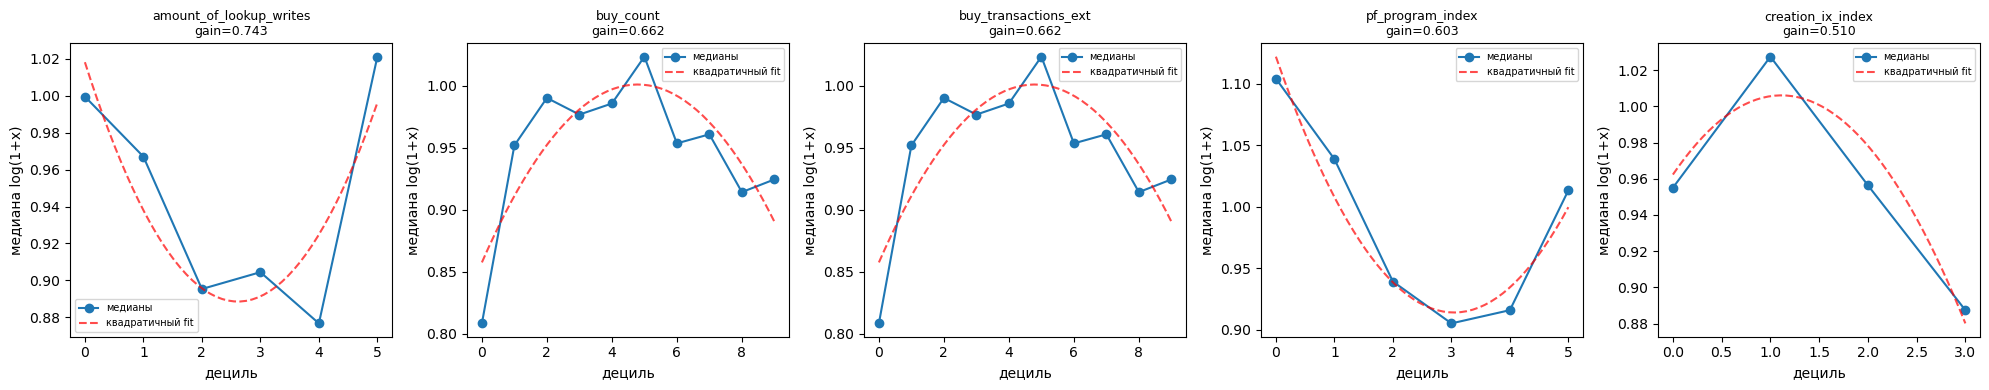

In [12]:
# Визуализация топ-5 нелинейных
top_nonlin = u_df.head(5)['feature'].tolist()
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, feat in enumerate(top_nonlin):
    x = df[feat].values.astype(float)
    q_edges = np.quantile(x, np.linspace(0, 1, 11))
    q_edges = np.unique(q_edges)
    bins = np.digitize(x, q_edges[1:-1])
    med = np.array([np.median(y_log[bins == b])
                    for b in range(len(q_edges)-1) if (bins==b).sum() > 0])
    ranks = np.arange(len(med))
    axes[i].plot(ranks, med, 'o-', color='C0', label='медианы')
    p2 = np.polyfit(ranks, med, 2)
    xx = np.linspace(0, len(med)-1, 50)
    axes[i].plot(xx, np.polyval(p2, xx), 'r--', alpha=0.7, label='квадратичный fit')
    axes[i].set_title(f'{feat}\ngain={u_df.iloc[i]["quad_gain"]:.3f}', fontsize=9)
    axes[i].set_xlabel('дециль'); axes[i].set_ylabel('медиана log(1+x)')
    axes[i].legend(fontsize=7)
plt.tight_layout()
plt.savefig('/tmp/feature_research/nonmonotonic_top5.png', dpi=110, bbox_inches='tight')
plt.show()

### Как читать?

- **U-форма** (низкие по краям, высокие в середине) — редкость. Обычно нет.
- **Inverted-U** (высокие по краям, низкие в середине) — тоже редкость.
- Чаще всего нелинейность просто означает что дальнейшее увеличение фичи не даёт роста таргета (saturation).

Для модели: если дерево решений делает 2+ split по этой фиче — нелинейность учитывается автоматически.

## 8. Практическая польза: что дают топ фичи?

**ELI5**: Представим что мы *торгуем вслепую* — берём только токены где фича высокая (top-10%) и смотрим сколько из них действительно взлетят в x >= 5.

Сравниваем с **base rate = 11%** (случайный выбор даёт 11% успешных).

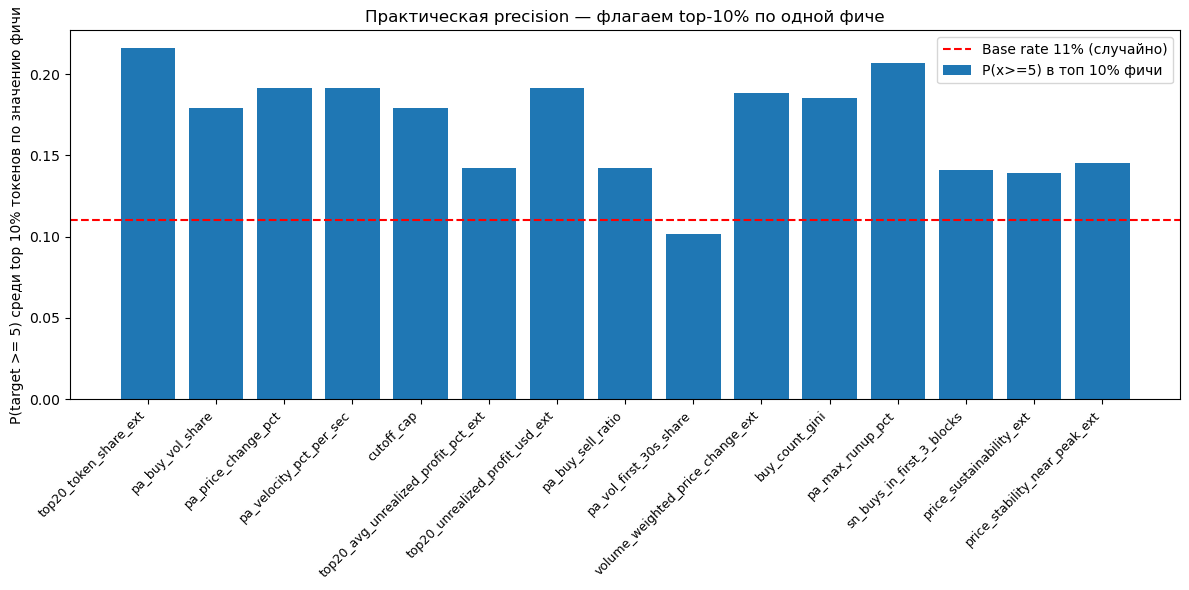

ТОП-15 фичей — top-decile P(x>=5):
                            feature  top_decile_5x_rate  bottom_decile_5x_rate  top_over_bottom_5x_ratio
              top20_token_share_ext              0.2160                 0.0988                    2.1875
                   pa_buy_vol_share              0.1790                 0.0710                    2.5217
                pa_price_change_pct              0.1914                 0.0988                    1.9375
            pa_velocity_pct_per_sec              0.1914                 0.0957                    2.0000
                         cutoff_cap              0.1790                 0.1451                    1.2340
top20_avg_unrealized_profit_pct_ext              0.1420                 0.0864                    1.6429
    top20_unrealized_profit_usd_ext              0.1914                 0.1358                    1.4091
                  pa_buy_sell_ratio              0.1420                 0.0708                    2.0062
             pa_vol_

In [13]:
top15 = combo_sorted.head(15)
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(top15))
ax.bar(x_pos, top15['top_decile_5x_rate'].values, color='C0', label='P(x>=5) в топ 10% фичи')
ax.axhline(0.1105, color='red', linestyle='--', label='Base rate 11% (случайно)')
ax.set_xticks(x_pos)
ax.set_xticklabels(top15['feature'].values, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('P(target >= 5) среди top 10% токенов по значению фичи')
ax.set_title('Практическая precision — флагаем top-10% по одной фиче')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/feature_research/top15_top_decile_5x_rate.png', dpi=110, bbox_inches='tight')
plt.show()

print('ТОП-15 фичей — top-decile P(x>=5):')
print(top15[['feature', 'top_decile_5x_rate', 'bottom_decile_5x_rate',
             'top_over_bottom_5x_ratio']].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

### Как читать?

- **Синий столбик выше красной линии** → фича реально помогает
- **Чем выше столбик** → тем полезнее фича если использовать её *одну* как критерий отбора

На практике модель использует *сочетание* фичей (например "top_decile по фиче A И top_decile по фиче B") и получает более высокую precision чем любая фича отдельно.

## 9. Статистические тесты — не случайность ли это?

**ELI5**: Может быть top-decile 5x-rate = 22% просто потому что нам повезло? Проверяем биномиальным тестом: "Какова вероятность что из N токенов K или больше окажутся x>=5, если базовая вероятность = 11%?"

Если p-value < 0.05 — маловероятно что случайность. Чем меньше p-value, тем надёжнее сигнал.

- `***` означает p < 0.001 (супер надёжно)
- `**` значит p < 0.01
- `*` значит p < 0.05

In [14]:
from scipy.stats import binomtest

print('Биномиальный тест: top-decile 5x-rate vs base rate 11.05%')
print('Нулевая гипотеза: фича не влияет, top-decile ведёт себя как остальные\n')
print(f'{"feature":<42}{"top_n":<7}{"x>=5":<6}{"rate":<8}{"p-value":<12}sig')
for _, row in combo_sorted.head(20).iterrows():
    f = row['feature']
    x = df[f].values.astype(float)
    q90 = np.quantile(x, 0.9)
    top = y[x >= q90]
    n = len(top); k = int((top >= 5).sum())
    if n == 0: continue
    res = binomtest(k, n, p=0.1105, alternative='greater')
    sig = '***' if res.pvalue < 0.001 else '**' if res.pvalue < 0.01 else '*' if res.pvalue < 0.05 else ''
    print(f'{f:<42}{n:<7}{k:<6}{k/n:<8.3f}{res.pvalue:<12.6f}{sig}')

Биномиальный тест: top-decile 5x-rate vs base rate 11.05%
Нулевая гипотеза: фича не влияет, top-decile ведёт себя как остальные

feature                                   top_n  x>=5  rate    p-value     sig
top20_token_share_ext                     324    70    0.216   0.000000    ***
pa_buy_vol_share                          324    58    0.179   0.000163    ***
pa_price_change_pct                       324    62    0.191   0.000013    ***
pa_velocity_pct_per_sec                   324    62    0.191   0.000013    ***
cutoff_cap                                324    58    0.179   0.000163    ***
top20_avg_unrealized_profit_pct_ext       324    46    0.142   0.046535    *
top20_unrealized_profit_usd_ext           324    62    0.191   0.000013    ***
pa_buy_sell_ratio                         324    46    0.142   0.046535    *
pa_vol_first_30s_share                    324    33    0.102   0.715579    
volume_weighted_price_change_ext          324    61    0.188   0.000025    ***
buy_count

## 10. Итоги и рекомендации

### Что мы узнали

1. **75 фичей отранжированы** по общему влиянию на таргет — см. `combined_score`.

2. **Топ-10 фичей** по комбинированному рейтингу:
   - `top20_token_share_ext` — лидер (top-decile precision 21.6% = 2x базовой)
   - `pa_buy_vol_share`, `pa_price_change_pct`, `pa_velocity_pct_per_sec`, `cutoff_cap`
   - `top20_avg_unrealized_profit_pct_ext`, `top20_unrealized_profit_usd_ext`
   - `pa_buy_sell_ratio`, `pa_vol_first_30s_share`, `volume_weighted_price_change_ext`

3. **Корреляционная матрица** показывает дубли среди топа:
   - Про-ценовые фичи: pa_price_change_pct ↔ pa_velocity_pct_per_sec
   - Про-top20: top20_token_share, top20_unrealized_profit, top20_avg_unrealized_pct
   - Используя всех сразу — избыточность

4. **Нелинейные паттерны** редки. Большинство фичей монотонные.

5. **Статистическая значимость**: топ фичи выдают p-value < 0.001 (супер надёжно, не случайность).

### Рекомендации для моделирования

- Приоритет фичам с высоким combined_score И значимым top-decile test
- Два коррелированных топа (>0.8) — можно оставить один
- Попробовать *взаимодействия* топ-фичей (например top20_token_share * pa_buy_vol_share)
- Фичи с низким combined_score во всех метриках — кандидаты на удаление (шум)

### Следующие шаги

- Feature elimination: убрать bottom-ranked фичи, переобучить champion модель, сравнить
- Feature engineering: interaction terms из топ-монотонных фичей
- Использовать combined_score в ensemble моделях как вес

In [15]:
# Сохраняем финальный ранкинг для следующих шагов
combo_sorted[['feature', 'spearman', 'pearson_on_logy', 'decile_monot_r2_signed',
              'mse_reduction', 'decile_med_lift_log', 'top_decile_5x_rate',
              'top_over_bottom_5x_ratio', 'combined_score']].to_csv(
    '/tmp/feature_research/feature_influence_ranked.csv', index=False)
print('Сохранил /tmp/feature_research/feature_influence_ranked.csv')
combo_sorted.head(30)[['feature', 'combined_score', 'spearman', 'mse_reduction', 'top_decile_5x_rate']]

Сохранил /tmp/feature_research/feature_influence_ranked.csv


,feature,combined_score,spearman,mse_reduction,top_decile_5x_rate
0,top20_token_share_ext,4.436305,0.138797,396.767326,0.216049
1,pa_buy_vol_share,4.016445,0.207101,24.494725,0.179012
2,pa_price_change_pct,3.721598,0.216708,51.183417,0.191358
3,pa_velocity_pct_per_sec,3.713721,0.215210,50.811686,0.191358
4,cutoff_cap,3.573782,0.200757,157.048843,0.179012
5,top20_avg_unrealized_profit_pct_ext,3.322967,0.211736,54.472823,0.141975
6,top20_unrealized_profit_usd_ext,3.237915,0.166832,95.899556,0.191358
7,pa_buy_sell_ratio,3.069062,0.153392,26.582218,0.141975
8,pa_vol_first_30s_share,3.054428,-0.108756,903.765908,0.101852
9,volume_weighted_price_change_ext,2.934977,0.111908,232.387175,0.188272
